In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
tomato=pd.read_csv("tamato.csv")

 data of single crop in a particular market of jaipur price data of 5 years

In [32]:
tomato

,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,1,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,200,400,300,04-Jun-20
1,2,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,300,600,450,05-May-25
2,3,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,300,600,450,06-May-25
3,4,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,300,600,450,18-Jun-21
4,5,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,300,700,500,07-May-25
...,...,...,...,...,...,...,...,...,...,...
566,567,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,8000,12500,10250,04-Aug-23
567,568,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,8000,13000,10500,11-Jul-23
568,569,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,10000,11000,10500,27-Jul-23
569,570,Jaipur,Jaipur (F&V),Tomato,Other,FAQ,10000,12000,11000,26-Jul-23


In [24]:
tomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Sl no.                     571 non-null    int64 
 1   District Name              571 non-null    object
 2   Market Name                571 non-null    object
 3   Commodity                  571 non-null    object
 4   Variety                    571 non-null    object
 5   Grade                      571 non-null    object
 6   Min Price (Rs./Quintal)    571 non-null    int64 
 7   Max Price (Rs./Quintal)    571 non-null    int64 
 8   Modal Price (Rs./Quintal)  571 non-null    int64 
 9   Price Date                 571 non-null    object
dtypes: int64(4), object(6)
memory usage: 44.7+ KB


 Data contain no null values 

In [30]:
tomato["District Name"].nunique()

1

In [38]:
location=tomato["District Name"].iloc[1]

In [40]:
location

'Jaipur'

In [42]:
market=tomato["Market Name"].iloc[1]

In [44]:
market

'Jaipur (F&V)'

In [46]:
commodity=tomato["Commodity"].iloc[1]

Since there is single values in this col we store them in case of future use and remve the col 

In [53]:
tomato.drop(["District Name","Market Name","Commodity","Sl no.","Variety"],axis=1,inplace=True)

In [55]:
tomato

,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,FAQ,200,400,300,04-Jun-20
1,FAQ,300,600,450,05-May-25
2,FAQ,300,600,450,06-May-25
3,FAQ,300,600,450,18-Jun-21
4,FAQ,300,700,500,07-May-25
...,...,...,...,...,...
566,FAQ,8000,12500,10250,04-Aug-23
567,FAQ,8000,13000,10500,11-Jul-23
568,FAQ,10000,11000,10500,27-Jul-23
569,FAQ,10000,12000,11000,26-Jul-23


Now convert the date time  so we can use ml models on it

In [67]:
tomato["Price Date"]=pd.to_datetime(tomato["Price Date"],format='%d-%b-%y')

In [69]:
tomato

,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
0,FAQ,200,400,300,2020-06-04
1,FAQ,300,600,450,2025-05-05
2,FAQ,300,600,450,2025-05-06
3,FAQ,300,600,450,2021-06-18
4,FAQ,300,700,500,2025-05-07
...,...,...,...,...,...
566,FAQ,8000,12500,10250,2023-08-04
567,FAQ,8000,13000,10500,2023-07-11
568,FAQ,10000,11000,10500,2023-07-27
569,FAQ,10000,12000,11000,2023-07-26


In [71]:
tomato["Price Date"].sort_values()

256   2020-01-09
157   2020-01-10
161   2020-01-13
155   2020-01-17
124   2020-01-20
         ...    
517   2025-07-29
519   2025-07-30
502   2025-08-01
520   2025-08-08
521   2025-08-11
Name: Price Date, Length: 571, dtype: datetime64[ns]

In [75]:
tomato=tomato.sort_values(by=["Price Date"])

In [77]:
tomato

,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
256,FAQ,1000,2100,1550,2020-01-09
157,FAQ,700,1500,1100,2020-01-10
161,FAQ,700,1700,1200,2020-01-13
155,FAQ,700,1400,1050,2020-01-17
124,FAQ,600,1500,1050,2020-01-20
...,...,...,...,...,...
517,FAQ,4200,4800,4500,2025-07-29
519,FAQ,4400,4800,4600,2025-07-30
502,FAQ,4000,4800,4400,2025-08-01
520,FAQ,4500,4800,4650,2025-08-08


<Axes: xlabel='Min Price (Rs./Quintal)'>

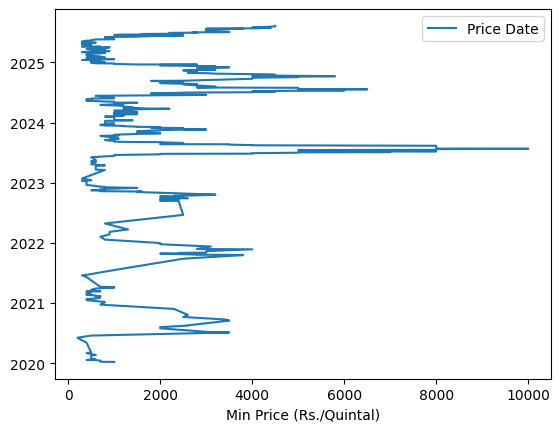

In [96]:
tomato.plot(kind='line',x='Min Price (Rs./Quintal)',y='Price Date')

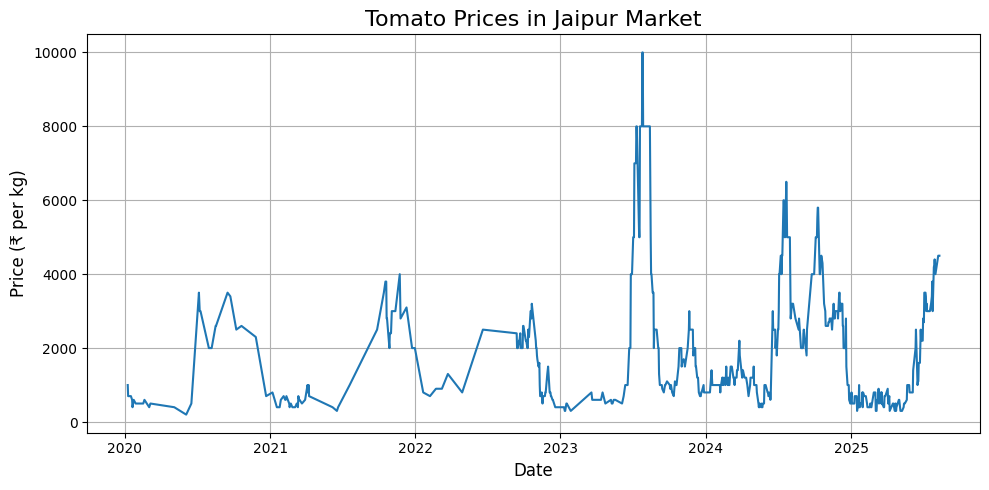

In [94]:
plt.figure(figsize=(10,5)) 
plt.plot(tomato["Price Date"],tomato["Min Price (Rs./Quintal)"])
plt.title("Tomato Prices in Jaipur Market", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (₹ per kg)", fontsize=12)

plt.grid(True)  # show grid lines
plt.tight_layout()
plt.show()

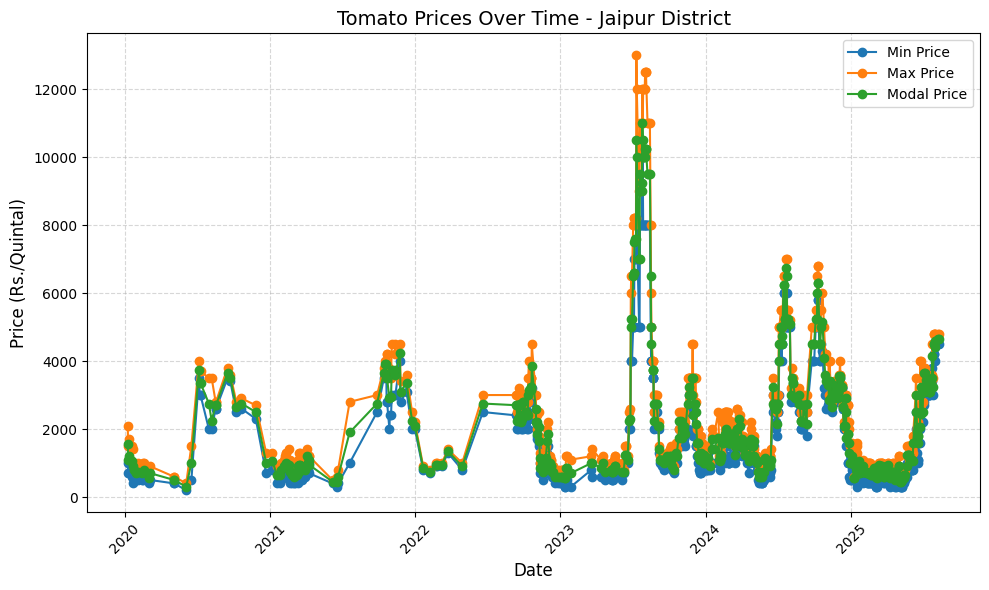

In [104]:
plt.figure(figsize=(10,6))
plt.plot(tomato['Price Date'], tomato['Min Price (Rs./Quintal)'], marker='o', label='Min Price')
plt.plot(tomato['Price Date'], tomato['Max Price (Rs./Quintal)'], marker='o', label='Max Price')
plt.plot(tomato['Price Date'], tomato['Modal Price (Rs./Quintal)'], marker='o', label='Modal Price')

plt.title('Tomato Prices Over Time - Jaipur District', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (Rs./Quintal)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

let see when the peak price occur 

In [110]:
tomato.sort_values(by="Min Price (Rs./Quintal)",ascending=False)

,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date
568,FAQ,10000,11000,10500,2023-07-27
569,FAQ,10000,12000,11000,2023-07-26
560,FAQ,8000,12000,10000,2023-08-01
567,FAQ,8000,13000,10500,2023-07-11
561,FAQ,8000,12000,10000,2023-07-12
...,...,...,...,...,...
13,FAQ,300,900,600,2025-03-05
15,FAQ,300,1100,700,2023-01-27
8,FAQ,300,800,550,2025-03-06
3,FAQ,300,600,450,2021-06-18


In [113]:
tomato["Min Price (Rs./Quintal)"].mean()

1929.0718038528896

In [115]:
tomato["Min Price (Rs./Quintal)"].median()

1200.0

In [124]:
# Save the cleaned dataset to CSV
tomato.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved as cleaned_data.csv")


Cleaned data saved as cleaned_data.csv
